<a href="https://colab.research.google.com/github/Papekyan/Data-Science-Project/blob/main/GB_XGBoost.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [5]:

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import recall_score,precision_score, confusion_matrix, classification_report
from sklearn.model_selection import cross_val_score
from sklearn.ensemble import GradientBoostingClassifier

In [6]:
df = pd.read_csv('financial_fraud.csv')

In [7]:
df.info()
df.head()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000000 entries, 0 to 4999999
Data columns (total 18 columns):
 #   Column                       Dtype  
---  ------                       -----  
 0   transaction_id               object 
 1   timestamp                    object 
 2   sender_account               object 
 3   receiver_account             object 
 4   amount                       float64
 5   transaction_type             object 
 6   merchant_category            object 
 7   location                     object 
 8   device_used                  object 
 9   is_fraud                     bool   
 10  fraud_type                   object 
 11  time_since_last_transaction  float64
 12  spending_deviation_score     float64
 13  velocity_score               int64  
 14  geo_anomaly_score            float64
 15  payment_channel              object 
 16  ip_address                   object 
 17  device_hash                  object 
dtypes: bool(1), float64(4), int64(1), object(1

,transaction_id,timestamp,sender_account,receiver_account,amount,transaction_type,merchant_category,location,device_used,is_fraud,fraud_type,time_since_last_transaction,spending_deviation_score,velocity_score,geo_anomaly_score,payment_channel,ip_address,device_hash
0,T100000,2023-08-22T09:22:43.516168,ACC877572,ACC388389,343.78,withdrawal,utilities,Tokyo,mobile,False,NaN,NaN,-0.21,3,0.22,card,13.101.214.112,D8536477
1,T100001,2023-08-04T01:58:02.606711,ACC895667,ACC944962,419.65,withdrawal,online,Toronto,atm,False,NaN,NaN,-0.14,7,0.96,ACH,172.52.47.194,D2622631
2,T100002,2023-05-12T11:39:33.742963,ACC733052,ACC377370,2773.86,deposit,other,London,pos,False,NaN,NaN,-1.78,20,0.89,card,185.98.35.23,D4823498
3,T100003,2023-10-10T06:04:43.195112,ACC996865,ACC344098,1666.22,deposit,online,Sydney,pos,False,NaN,NaN,-0.60,6,0.37,wire_transfer,107.136.36.87,D9961380
4,T100004,2023-09-24T08:09:02.700162,ACC584714,ACC497887,24.43,transfer,utilities,Toronto,mobile,False,NaN,NaN,0.79,13,0.27,ACH,108.161.108.255,D7637601


In [8]:
X = df.drop(['is_fraud','fraud_type'], axis=1)
Y = df['is_fraud']

In [9]:
Y = Y.map({False: -1, True: 1})

Y.value_counts()

,count
is_fraud,
-1,4820447
1,179553


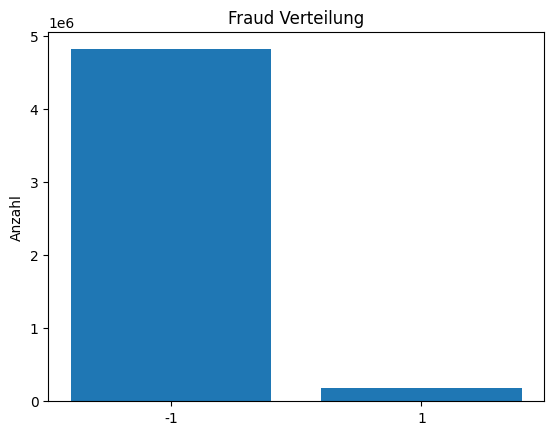

In [10]:
counts = Y.value_counts().sort_index()
plt.bar(counts.index.astype(str), counts.values)
plt.xlabel('')
plt.ylabel('Anzahl')
plt.title('Fraud Verteilung')
plt.xticks(rotation=0)
plt.show()

In [11]:
X['timestamp_str'] = X['timestamp'].astype(str)

# 2. Nimm nur die ersten 19 Zeichen, also "YYYY-MM-DDTHH:MM:SS"
#    (Index 0–18; 19 Zeichen insgesamt)
X['timestamp_trimmed'] = X['timestamp_str'].str.slice(0, 19)

# 3. Konvertiere die abgeschnittene Zeichenkette in datetime
X['timestamp'] = pd.to_datetime(X['timestamp_trimmed'])
X['timestamp'].head()
X['timestamp'].info()

<class 'pandas.core.series.Series'>
RangeIndex: 5000000 entries, 0 to 4999999
Series name: timestamp
Non-Null Count    Dtype         
--------------    -----         
5000000 non-null  datetime64[ns]
dtypes: datetime64[ns](1)
memory usage: 38.1 MB


In [12]:
X['year']   = X['timestamp'].dt.year
X['month']  = X['timestamp'].dt.month
X['day']    = X['timestamp'].dt.day
X['hour']   = X['timestamp'].dt.hour
X['weekday'] = X['timestamp'].dt.weekday

In [13]:
obj_card = X.select_dtypes(include='object').nunique().sort_values(ascending=False)
print(obj_card)

transaction_id       5000000
timestamp_str        4999998
ip_address           4997068
timestamp_trimmed    4623346
device_hash          3835723
receiver_account      896639
sender_account        896513
location                   8
merchant_category          8
transaction_type           4
payment_channel            4
device_used                4
dtype: int64


In [14]:
to_encode = [
    'merchant_category',
    'location',
    'transaction_type',
    'device_used',
    'payment_channel'
]


cols_to_drop = [
    'transaction_id',
    'ip_address',
    'device_hash',
    'sender_account',
    'receiver_account',
    'timestamp_str',
    'timestamp_trimmed',
    'timestamp'

]
X_encoded = pd.get_dummies(X, columns=to_encode, drop_first=True)

X = X_encoded.drop(columns=cols_to_drop, errors='ignore')



In [15]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

In [16]:
X.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000000 entries, 0 to 4999999
Data columns (total 33 columns):
 #   Column                         Dtype  
---  ------                         -----  
 0   amount                         float64
 1   time_since_last_transaction    float64
 2   spending_deviation_score       float64
 3   velocity_score                 int64  
 4   geo_anomaly_score              float64
 5   year                           int32  
 6   month                          int32  
 7   day                            int32  
 8   hour                           int32  
 9   weekday                        int32  
 10  merchant_category_grocery      bool   
 11  merchant_category_online       bool   
 12  merchant_category_other        bool   
 13  merchant_category_restaurant   bool   
 14  merchant_category_retail       bool   
 15  merchant_category_travel       bool   
 16  merchant_category_utilities    bool   
 17  location_Dubai                 bool   
 18  lo

In [17]:
X.isnull().sum()

,0
amount,0
time_since_last_transaction,896513
spending_deviation_score,0
velocity_score,0
geo_anomaly_score,0
year,0
month,0
day,0
hour,0
weekday,0


In [18]:
median_val = X['time_since_last_transaction'].median()

X['time_since_last_transaction'] = X['time_since_last_transaction'].fillna(median_val)

In [35]:
gbr = GradientBoostingClassifier(subsample=0.001,verbose=1)


In [36]:
X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size=0.2, random_state=42, stratify=Y)

In [37]:
modell = gbr.fit(X_train,Y_train)

      Iter       Train Loss      OOB Improve   Remaining Time 
         1           0.3119           0.0013            1.71m
         2           0.3274           0.0012            1.46m
         3           0.2855           0.0001            1.30m
         4           0.3117          -0.0001            1.13m
         5           0.3163           0.0001            1.05m
         6           0.3099          -0.0001           59.72s
         7           0.2810          -0.0001           57.32s
         8           0.2882          -0.0004           55.86s
         9           0.3024           0.0003           54.48s
        10           0.3172          -0.0000           53.45s
        20           0.3158          -0.0007           44.44s
        30           0.3511          -0.0000           42.46s
        40           0.3042          -0.0003           34.95s
        50           0.3114           0.0005           28.41s
        60           0.3119           0.0000           23.11s
       

In [38]:
#cross_val_score(gbr, X_train, Y_train, cv=2, scoring='f1', n_jobs=-1).mean()

In [23]:
Y_pred = gbr.fit(X_train,Y_train).predict(X_test)

In [24]:
import pickle
pickle.dump(gbr, open("gbr.pickle.dat", "wb"))

In [32]:
prec = precision_score(Y_test, Y_pred)
rec  = recall_score(Y_test, Y_pred)
print(prec, rec)


0.0 0.0


In [33]:


# Anzahl der Vorhersagen pro Label anzeigen
(unique, counts) = np.unique(Y_pred, return_counts=True)
print(dict(zip(unique, counts)))

{np.int64(-1): np.int64(999999), np.int64(1): np.int64(1)}
